# Import Required Libraries

In [ ]:
#!pip install wordcloud

In [1]:
!pip install transformers datasets evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [2]:
import pandas as pd # to handle the dataframes

#to Vizualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk # provides functions for text preprocessing
nltk.download('stopwords')
nltk.download('punkt_tab') # Downloads the Punkt tokenizer models (used for splitting text into sentences and words)
from nltk.corpus import stopwords # Imports the stopwords list directly
from nltk.tokenize import word_tokenize  # splits text into individual words/tokens
from collections import Counter # counts occurrences of items

import string # for common string operations

from nltk.stem import WordNetLemmatizer # lemmatizing
from nltk.corpus import wordnet # to get the synsets of English words
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

from transformers import AutoTokenizer, AutoModelForSequenceClassification # Loads Hugging Face’s tokenizer  and the sequence classification model (for news classification)
from transformers import pipeline # Provides a high‑level API to quickly run tasks (e.g., text classification, question answering)
import torch #   allows to move computations from the CPU to GPUs

from sklearn.model_selection import train_test_split # Splits dataset into training and testing sets
from datasets import Dataset #  wrap your data into a format compatible with Transformers training pipelines

import evaluate #  standardized evaluation metrics
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer # defines hyperparameters , handle training

import numpy as np # Used for numerical operations
from sklearn.metrics import accuracy_score, f1_score # Imports specific evaluation metrics to measure classification performance.
from sklearn.metrics import accuracy_score, classification_report # Adds classification_report


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
from google.colab import drive # connect to google drive
drive.mount('/content/drive')

Mounted at /content/drive


# *Task 1: Preparing Data*

In [3]:
# read  csv files separately
business_df = pd.read_excel('/content/Business.xlsx')
opinion_df = pd.read_excel('/content/Opinion.xlsx')
political_gossip_df = pd.read_excel('/content/Political_gossip.xlsx')
sports_df = pd.read_excel('/content/Sports.xlsx')
world_news_df = pd.read_excel('/content/World_news.xlsx')

In [ ]:
# Add class column for each data frame
business_df['class'] = "Business"
opinion_df['class'] = "Opinion"
political_gossip_df['class'] = "Political_gossip"
sports_df['class'] = "Sports"
world_news_df['class'] = "World_news"

In [ ]:
# Remove title column from each data frame
business_df = business_df.drop(columns=['title'])
opinion_df = opinion_df.drop(columns=['title'])
political_gossip_df = political_gossip_df.drop(columns=['title'])
sports_df = sports_df.drop(columns=['title'])
world_news_df = world_news_df.drop(columns=['title'])

In [ ]:
# drop duplicated records if any
business_df.drop_duplicates(keep="first", inplace=True)
opinion_df.drop_duplicates(keep="first", inplace=True)
political_gossip_df.drop_duplicates(keep="first", inplace=True)
sports_df.drop_duplicates(keep="first", inplace=True)
world_news_df.drop_duplicates(keep="first", inplace=True)
# drop null records
business_df.dropna(inplace=True)
opinion_df.dropna(inplace=True)
political_gossip_df.dropna(inplace=True)
sports_df.dropna(inplace=True)


In [ ]:
# number of Records after removing Duplicates and null
print("business_df",business_df.shape)
print("opinion_df",opinion_df.shape)
print("political_gossip_df",political_gossip_df.shape)
print("sports_df",sports_df.shape)
print("world_news_df",world_news_df.shape)

business_df (208, 3)
opinion_df (209, 3)
political_gossip_df (209, 3)
sports_df (182, 3)
world_news_df (210, 3)


In [ ]:
# 3. Combine all Data Frames into one DataFrame
dataframes = [business_df, opinion_df, political_gossip_df, sports_df, world_news_df]
combined_df = pd.concat(dataframes, ignore_index=True)

In [ ]:

combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1018 entries, 0 to 1017
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1018 non-null   int64 
 1   content     1018 non-null   object
 2   class       1018 non-null   object
dtypes: int64(1), object(2)
memory usage: 24.0+ KB


In [ ]:
# 5. Save the final file
combined_df.to_excel('Daily_Mirror_News.xlsx', index=False)

# *Task 2: EDA*

In [ ]:
# read "Daily_Mirror_News.xlsx" file
combined_df = pd.read_excel('/content/Daily_Mirror_News.xlsx')

## 01.Distribution of News Categories








/tmp/ipykernel_6159/1019315717.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


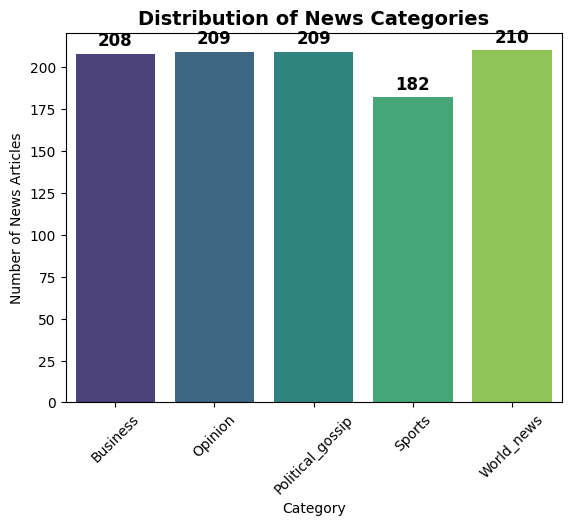

In [ ]:
# NEWS CLASS DISTRIBUTION WITH COUNTS
ax = sns.countplot(
    data=combined_df,
    x='class',
    palette='viridis'
)

plt.title('Distribution of News Categories', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of News Articles')
plt.xticks(rotation=45)

# Add count numbers on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=12, fontweight='bold')


plt.show()

## 02.Word Clouds
-  A beautiful picture where the size of the word = how often it appears.
Bigger word = more frequent.
- It gives you an instant visual summary of the main topics in the news.

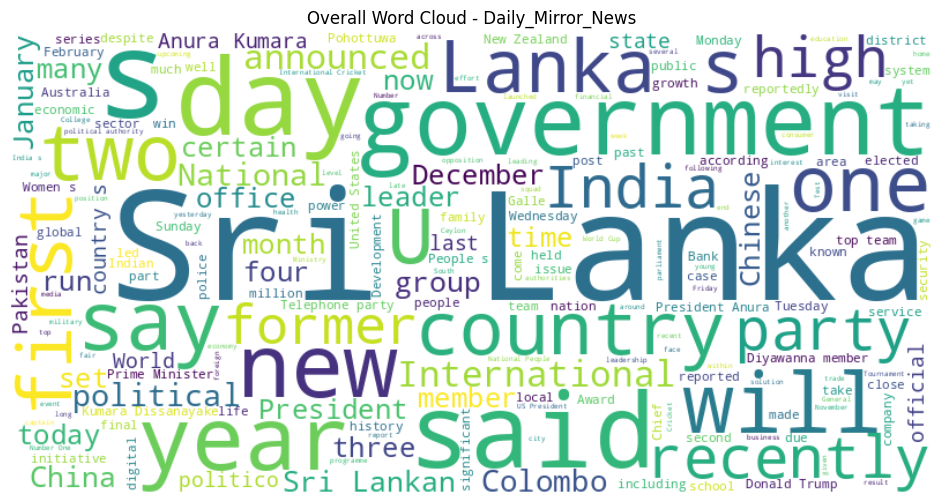

In [ ]:
# Overall Word Cloud
all_text = ' '.join(combined_df['content'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Word Cloud - Daily_Mirror_News')
plt.show()

## 03.Stopwords
- These are extremely common words like “the”, “is”, “and”, “to”, “of”,  etc. They appear in almost every sentence but don’t carry important meaning. Removing them helps the model focus on the real important words (e.g., “cricket”, “election”, “stock market”).

In [ ]:
# Get all stopwords from NLTK
stop_words = set(stopwords.words('english'))
print(stop_words)

{'don', 'doesn', "hasn't", 'until', "it'll", 'does', 'their', 'where', 'my', 'be', 'who', 'them', 'against', 'when', 'a', 'mustn', 'was', 'there', "he's", "we'd", "we'll", 'yours', 'own', 'some', "she'd", "i'd", 'our', 'ourselves', 'for', 'in', 'any', 'over', 'mightn', 'have', 'off', 'hadn', 'after', 'so', 'will', 'shan', 'needn', 't', "hadn't", 'did', 'shouldn', 'yourself', 'me', "mustn't", 'y', 'too', 'an', "isn't", 'd', 'no', 'as', 'down', 'its', 'i', 'further', 'myself', "we're", 'during', 'we', 'here', 'your', 'whom', "mightn't", 'with', 'while', 'being', 'all', 'o', 'through', 'and', "i'll", "wouldn't", 'm', 'out', 'should', 'couldn', 'she', 'ain', 'it', 'now', "it's", 'itself', 'because', 'doing', 'which', 'isn', 'from', 'each', "don't", 'only', "you'll", 'haven', 'once', 'under', "she's", 'about', 'do', "won't", "it'd", "shouldn't", "shan't", 'just', 'won', 'wouldn', 'very', 'above', 'are', "haven't", 'having', 'to', 'the', 'but', 'than', 'themselves', 'has', 'up', "you'd", "he

In [ ]:
# get stopwords in news content

def get_top_stopwords(text_series, n=20):
    all_stopwords = []
    for text in text_series:
        tokens = word_tokenize(str(text).lower())
        # Keep ONLY stopwords
        stopwords_in_text = [word for word in tokens if word in stop_words]
        all_stopwords.extend(stopwords_in_text)
    return Counter(all_stopwords).most_common(n)

# Get top 20 stopwords
top_stopwords = get_top_stopwords(combined_df['content'], n=20)

# Convert to DataFrame for easy plotting
stop_df = pd.DataFrame(top_stopwords, columns=['Stopword', 'Count'])




/tmp/ipykernel_5083/1853525148.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


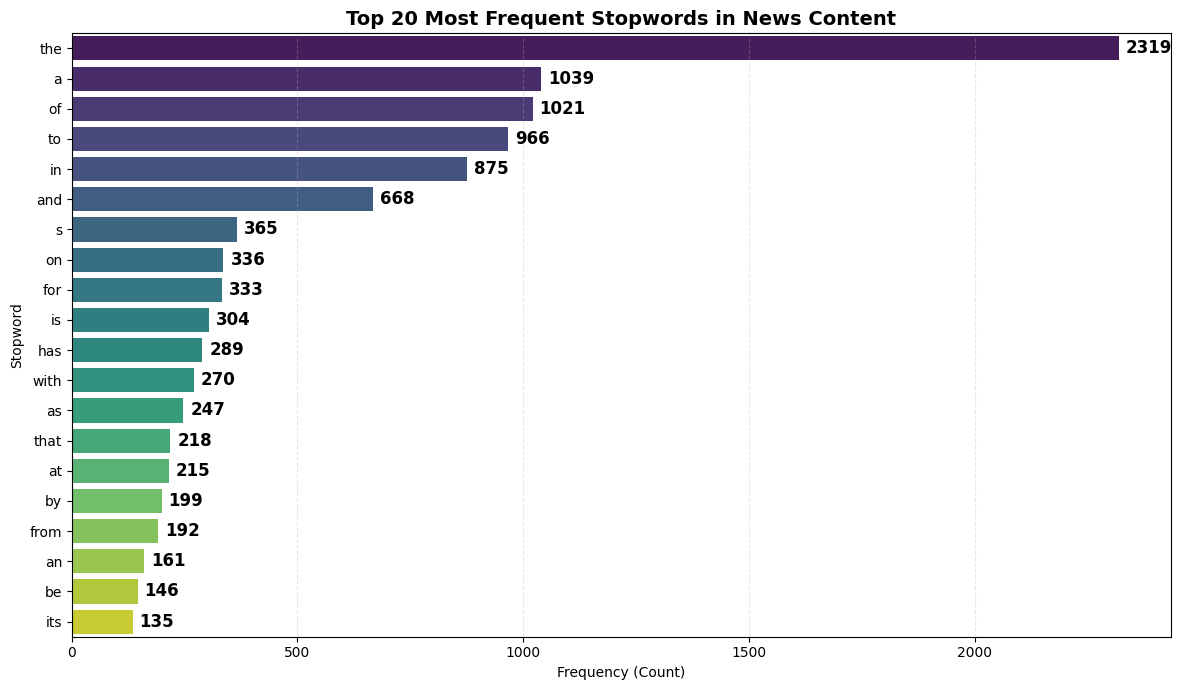

In [ ]:
#  Vizualize TOP 20  STOPWORDS
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=stop_df,
    x='Count',
    y='Stopword',
    palette='viridis'
)

plt.title('Top 20 Most Frequent Stopwords in News Content', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Count)')
plt.ylabel('Stopword')

# Add count numbers on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=5, fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 04.N-grams
Instead of looking at single words, we look at groups of 2 or 3 words that appear together.This shows common phrases and context that single words miss.

*  Bigram (2 words) → e.g., “Sri Lanka”, “stock market”, “political gossip”
*   Trigram (3 words) → e.g., “central bank rate”, “test match win”





In [ ]:
def get_ngrams(text_series, n=2, top=20):
    all_ngrams = []
    for text in text_series:
        tokens = word_tokenize(str(text).lower())
        tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
        ngrams = zip(*[tokens[i:] for i in range(n)])
        all_ngrams.extend([' '.join(ng) for ng in ngrams])
    return Counter(all_ngrams).most_common(top)

print("Top 20 Bigrams:")
print(get_ngrams(combined_df['content'], n=2))

print("\nTop 20 Trigrams:")
print(get_ngrams(combined_df['content'], n=3))

Top 20 Bigrams:
[('sri lanka', 271), ('sri lankan', 31), ('anura kumara', 28), ('kumara dissanayake', 27), ('donald trump', 26), ('new zealand', 25), ('president anura', 24), ('telephone party', 24), ('united states', 22), ('top team', 22), ('prime minister', 17), ('international cricket', 17), ('diyawanna members', 16), ('world cup', 16), ('people power', 15), ('number one', 15), ('national people', 14), ('political authority', 14), ('women world', 14), ('power npp', 13)]

Top 20 Trigrams:
[('anura kumara dissanayake', 27), ('president anura kumara', 23), ('national people power', 14), ('women world cup', 14), ('people power npp', 12), ('president donald trump', 12), ('top team member', 11), ('international cricket council', 11), ('sri lanka cricket', 11), ('icc women world', 9), ('turnover crossing rs', 8), ('crossing rs bn', 8), ('cricket council icc', 8), ('hatton national bank', 7), ('us president donald', 7), ('clean sri lanka', 7), ('prime minister narendra', 7), ('minister nare

# *Task:2 Preprocesssing*

## 01. Conversion to lowercase


*   Makes "Sri" and "sri" the same word. Prevents the model from
treating them as different.






In [ ]:
# initial text
combined_df['content'].iloc[6]

'AB Mauri Lanka is set to commemorate International Women’s Day 2025 with its flagship event “Empower Her”, on March 2 at the Sheraton Colombo Hotel, Colombo.'

In [ ]:
combined_df["content"] = combined_df["content"].str.lower()

In [ ]:
combined_df['content'].iloc[6]

'ab mauri lanka is set to commemorate international women’s day 2025 with its flagship event “empower her”, on march 2 at the sheraton colombo hotel, colombo.'

## 02.Remove Punctuations


- Punctuation often adds noise in text classification tasks. For example, commas, periods, and brackets don’t usually contribute to the meaning of a news content. Removing them helps normalize the text and reduce vocabulary size.
- choose to keep ', ", $, %, and ?. That’s because these symbols can carry semantic meaning in news content.those symbols are informative in our domain (news classification).

In [ ]:
# observe the punctuations in the string library
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# initial text
combined_df['content'].iloc[48]

'people’s bank announced the seamless integration of its people’s pay digital wallet app with ‘govpay,’ sri lanka’s groundbreaking digital payment platform.'

In [ ]:
# punctuations to be removed
punct_to_remove = string.punctuation.replace("'",'').replace('"','').replace('$','').replace('?','').replace('%','')
print(punct_to_remove)

# define the function
def remove_punctuation(text):
    #return text.translate(str.maketrans('', '', punct_to_remove)) # remove the specified ones
    return text.translate(str.maketrans('', '', string.punctuation)) # remove all the punctuations

# applying the function
combined_df["content"] = combined_df["content"].apply(remove_punctuation)

!#&()*+,-./:;<=>@[\]^_`{|}~


In [ ]:
# cleaned text
combined_df['content'].iloc[48]

'people’s bank announced the seamless integration of its people’s pay digital wallet app with ‘govpay’ sri lanka’s groundbreaking digital payment platform'

## 03.Lemmatization

- Lemmatization will brekdown all the words to their meaningful root form.




- Lemmatization wil look into the word form (verb, noun, adverb) before breaking the word into root form.




 - In news classification, this helps the model treat semantically related words as the same feature. For example, “won the match”, “winning the match”, and “win the match” all contribute to the **Sports** class.  

- Although news articles are more formal than social media text (so the benefit is moderate), lemmatization still helps reduce vocabulary size and improves model generalization on our relatively small dataset.



In [ ]:
# lookup a word
wordnet.synsets('looking')

[Synset('look.n.02'),
 Synset('looking.n.02'),
 Synset('look.v.01'),
 Synset('look.v.02'),
 Synset('look.v.03'),
 Synset('search.v.02'),
 Synset('front.v.01'),
 Synset('attend.v.02'),
 Synset('look.v.07'),
 Synset('expect.v.03'),
 Synset('look.v.09'),
 Synset('count.v.08'),
 Synset('looking.s.01')]

In [ ]:
# check for the description
print(wordnet.synset('look.n.02').definition())

the act of directing the eyes toward something and perceiving it visually


In [ ]:
combined_df['content'].iloc[186]

'Sri Lanka has set ambitious targets for tourist arrivals over the years, often without a strong foundation of research or analysis. Many such goals appear to be based more on optimism than practical realities.'

In [ ]:
# Step 4: Lemmatization (better than stemming for news)
def lematize_text(text):
    from nltk.stem import WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    text = ' '.join(tokens)


    return text

# Apply to sample and show changes
sample_text = combined_df['content'].iloc[186]
cleaned_sample = lematize_text(sample_text)

In [ ]:
print("4. After Lemmatization:\n", cleaned_sample[:500], "...\n")

4. After Lemmatization:
 Sri Lanka ha set ambitious target for tourist arrival over the year , often without a strong foundation of research or analysis . Many such goal appear to be based more on optimism than practical reality . ...



In [ ]:
# Apply to all rows
combined_df['content'] = combined_df['content'].astype(str).apply(lematize_text)

In [ ]:
# 5. Save the Preprocessed file
combined_df.to_excel(' Preprocessed_Daily_Mirror_News.xlsx', index=False)

# *Task 3: Select a Hugging Face Model*

## Selected Model
**Model Name:** `distilbert/distilbert-base-uncased`  
**Model Link:** [https://huggingface.co/distilbert/distilbert-base-uncased](https://huggingface.co/distilbert/distilbert-base-uncased)

## Justification for Selection


1. **Lightweight and Computationally Efficient**  
   -  it is smaller and faster than the original BERT model while retaining nearly the same performance. This makes it ideal for fine-tuning on our relatively small dataset  and for deployment in the Streamlit WebApp.

2. **Strong General Language Understanding**  
     - the model has excellent contextual understanding of English text, which is exactly what is needed before fine-tuning on a downstream task like news classification. The model creators themselves state that it is “mostly intended to be fine-tuned on a downstream task” — which is precisely what will be done in Task 4.

3. **Clean Starting Point (No Task Bias)**  
   - Unlike models that are already fine-tuned (e.g., `distilbert-base-uncased-finetuned-sst-2-english`) or zero-shot classification models, this raw base model has no pre-existing bias toward any specific task. This allowed it to learn our five specific classes (**Business, Opinion, Political gossip, Sports, World news**) effectively from our labeled Sri Lankan Daily Mirror news data.

4. **Proven Track Record in Text Classification**  
   - `distilbert-base-uncased` is one of the most widely used base models for text classification tasks worldwide. It has been successfully applied to news categorization, topic classification, and similar problems in both academic and industry projects.

5. **Easy to Fine-tune**:
      -  Works perfectly with Hugging Face `Trainer` API and       `AutoModelForSequenceClassification`.




 *Therefore, **`distilbert/distilbert-base-uncased`** provided the best balance of **performance, speed, ease of fine-tuning, and suitability** for this assignment.*










In [ ]:

# Load tokenizer and model
model_name = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,          # We have 5 classes
    id2label={
        0: "Business",
        1: "Opinion",
        2: "Political gossip",
        3: "Sports",
        4: "World news"
    },
    label2id={
        "Business": 0,
        "Opinion": 1,
        "Political gossip": 2,
        "Sports": 3,
        "World news": 4
    }
)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Create a pipeline for text classification using our loaded model
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
    device=0 if torch.cuda.is_available() else -1
)

In [ ]:
# Test model classification output using sample text
text_to_test=combined_df.iloc[96]['content']
result = classifier([text_to_test])
print(result)

[{'label': 'World news', 'score': 0.24303528666496277}]


# *Task 4: Finetune a Pre-trained Hugging Face Model*

### Prepare Data for Model Training

In [ ]:

# Map class names to numbers
label2id = {
    "Business": 0,
    "Opinion": 1,
    "Political_gossip": 2,
    "Sports": 3,
    "World_news": 4
}
combined_df['label'] = combined_df['class'].map(label2id)

# Train-validation split (80%-20%)
train_df, val_df = train_test_split(combined_df, test_size=0.2, stratify=combined_df['label'], random_state=42)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Training samples: 814
Validation samples: 204


In [ ]:
combined_df.head()

,Unnamed: 0,content,class,label
0,0,sri lanka ’ s inflation is expected to increas...,Business,0
1,1,president anura kumara dissanayake,Business,0
2,2,a artificial intelligence ai evolves from bein...,Business,0
3,3,a group of ride for ceylon participant from th...,Business,0
4,4,the aspi closed in green a a result of price g...,Business,0


In [ ]:

def tokenize_function(examples):
    return tokenizer(examples['content'], padding="max_length", truncation=True, max_length=512)

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['content', 'label']])
val_dataset   = Dataset.from_pandas(val_df[['content', 'label']])

# Tokenize
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function, batched=True)

# Remove original text column (not needed for training)
train_dataset = train_dataset.remove_columns(['content'])
val_dataset   = val_dataset.remove_columns(['content'])



Map:   0%|          | 0/814 [00:00<?, ? examples/s]

Map:   0%|          | 0/204 [00:00<?, ? examples/s]

### Configure Training Parameters

In [ ]:

# Metric
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,           # Small dataset → 4 epochs is enough
    weight_decay=0.01,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"              # No wandb
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

### Fine Tuning The Model

In [ ]:
print("🚀 Starting fine-tuning...")
trainer.train()

🚀 Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.649705,0.605031,0.867647
2,0.274729,0.359281,0.901961
3,0.141949,0.325914,0.901961
4,0.047217,0.334728,0.897059


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=408, training_loss=0.4383907975519405, metrics={'train_runtime': 195.9294, 'train_samples_per_second': 16.618, 'train_steps_per_second': 2.082, 'total_flos': 431336925634560.0, 'train_loss': 0.4383907975519405, 'epoch': 4.0})

### Model Evaluation

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

trainer.compute_metrics = compute_metrics
trainer.evaluate()

{'eval_loss': 0.3592633306980133,
 'eval_accuracy': 0.9019607843137255,
 'eval_f1': 0.9012253784405355,
 'eval_runtime': 2.953,
 'eval_samples_per_second': 69.081,
 'eval_steps_per_second': 8.804,
 'epoch': 4.0}

In [ ]:
predictions = trainer.predict(val_dataset)
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

print("Accuracy:", accuracy_score(labels, preds))
print(classification_report(labels, preds, target_names=list(model.config.id2label.values())))

Accuracy: 0.9019607843137255
                  precision    recall  f1-score   support

        Business       0.92      0.83      0.88        42
         Opinion       0.80      0.79      0.80        42
Political gossip       0.98      1.00      0.99        42
          Sports       0.97      1.00      0.99        36
      World news       0.84      0.90      0.87        42

        accuracy                           0.90       204
       macro avg       0.90      0.90      0.90       204
    weighted avg       0.90      0.90      0.90       204



### Saving Fine Tuned Model & Push to Hugging Face

In [ ]:
# Locally Save the model & tokenizer
trainer.save_model("/content/my_model")
tokenizer.save_pretrained("/content/my_model")


In [ ]:
# Login to hugging face
from huggingface_hub import login
login()   # ← Paste  Hugging Face write token here when asked

In [ ]:
# Push the fine-tuned model back to the Hugging Face model hub
repo_name = "Ginidu2003/Distilbert-Base-News-classifier"

trainer.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)



Link to Fine Tuned Model
- https://huggingface.co/Ginidu2003/Distilbert-Base-News-classifier

Link to APP on Hugging Face Space
- https://huggingface.co/spaces/Ginidu2003/News_Classifier